# LOAD LIBRARIES

In [34]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import math
import json
from sklearn.model_selection import StratifiedShuffleSplit, StratifiedKFold
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import root_mean_squared_error, r2_score
import shap
from diive.core.io.files import save_parquet, load_parquet
from datetime import datetime
from gapfilling_utils_v2 import (
    setup_log_transform,
    undersample_target,
    plot_cv_splits,
    create_block_splits,
    crossval_evaluate,
    build_df_for_parcel,
    fit_gapfill_ts,
    apply_gapfill_ts
)

# CONFIGURATION

In [35]:
START_DATE, END_DATE = '2023-11-07', '2024-01-21'
TARGET_FLUX = 'FN2O'
RAND_ERR_COL = "FN2O_RANDUNC_HF"  # EddyPro random uncertainty col
N_FOLDS = 10
MODEL_TYPE = 'XGBoost'  # Options: 'RandomForest' or 'XGBoost'
PARCEL_CERTAIN = True
LOG_TRANSFORM = True
ADD_ID = True
UNDERSAMPLE = False
ADD_TRT = True
USTAR_CUT = 'CUT_50'

# LOAD DATA

In [36]:
data_main = fluxes = load_parquet(filepath=r"82.1.1_GapFillingDataset.parquet")
data_main = data_main.loc[START_DATE:END_DATE].copy()
maindf = data_main.copy()

# Add an id column to account for the proximity of values as the timestamp is continuous without gaps
if ADD_ID:
    data_main['id'] = range(0, len(data_main))
    print("\nAdded 'id' variable --> indexing number starting from zero")
else:
    print('\nNot using index variable')

# Keep only data where we are sure about parcel attribution
if PARCEL_CERTAIN:
    data_main = data_main[data_main['parcel_certainty'] == 'certain'].copy()
    print('\nKeeping only data when we are highly confident on the parcel attribution')
else:
    print('\nKeeping also data from mixed parcel contribution')


TARGET = f'{TARGET_FLUX}_L3.3_CUT_50_QCF0'
print(f'The target variable is {TARGET}')

data_main

Loaded .parquet file 82.1.1_GapFillingDataset.parquet (0.321 seconds).
    --> Detected time resolution of <30 * Minutes> / 30min 

Added 'id' variable --> indexing number starting from zero

Keeping only data when we are highly confident on the parcel attribution
The target variable is FN2O_L3.3_CUT_50_QCF0


,NEE_L3.3_CUT_50_QCF,FN2O_L3.3_CUT_50_QCF,FCH4_L3.3_CUT_50_QCF,NEE_L3.3_CUT_50_QCF0,FN2O_L3.3_CUT_50_QCF0,FCH4_L3.3_CUT_50_QCF0,RECO_NT_CUT_50_gfXG_QCF0,GPP_NT_CUT_50_gfXG_QCF0,parcel,parcel_certainty,trt,FN2O_RANDUNC_HF,SW_IN_POT,prec,ta,...,wfps_0.15_gfXG_diff24h,wfps_0.3_gfXG_diff6h,wfps_0.3_gfXG_diff12h,wfps_0.3_gfXG_diff24h,n_decay_linear,n_decay_logistic,n_decay_exponential,n_decay_lognormal,n_decay_timed,timesince_fert,timesince_fert_min,timesince_fert_org,LAI,can_height,id
TIMESTAMP_MIDDLE,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2023-11-07 15:45:00,NaN,NaN,NaN,NaN,NaN,NaN,1.640426,1.734944,B,certain,1.0,0.205045,267.16400,0.0,7.366667,...,-0.431489,0.024631,0.162343,0.396048,0.0,0.0,2.280252,1.041116,29.0,22.0,30.0,22.0,0.300625,5.003883,31
2023-11-07 16:15:00,NaN,0.324973,-4.360399,NaN,0.324973,NaN,1.638105,0.935265,B,certain,1.0,0.124789,168.35800,0.0,7.300000,...,-0.444220,0.167777,0.543725,0.460355,0.0,0.0,2.274546,1.037818,29.0,22.0,30.0,22.0,0.300629,5.003909,32
2023-11-07 17:15:00,NaN,0.339963,2.488800,NaN,0.339963,2.488800,1.613576,0.130147,B,certain,1.0,0.264532,3.38364,0.5,6.600000,...,-0.431704,0.616304,0.924230,0.889783,0.0,0.0,2.263177,1.031258,29.0,22.0,30.0,22.0,0.300637,5.003963,34
2023-11-07 17:45:00,NaN,-0.983566,-9.177059,NaN,-0.983566,-9.177059,1.614751,0.131321,B,certain,1.0,0.344428,0.00000,0.2,6.633333,...,-0.346287,1.127378,1.389628,1.462444,0.0,0.0,2.257514,1.027996,29.0,22.0,30.0,22.0,0.300642,5.003990,35
2023-11-07 18:15:00,NaN,-0.064456,NaN,NaN,-0.064456,NaN,1.605338,0.101225,B,certain,1.0,0.172716,0.00000,0.5,6.366667,...,-0.150212,1.555405,1.858603,1.930903,0.0,0.0,2.251865,1.024747,29.0,22.0,30.0,22.0,0.300646,5.004017,36
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-01-21 21:15:00,NaN,0.414013,NaN,NaN,NaN,NaN,1.190825,-0.438207,B,certain,1.0,0.188048,0.00000,0.0,-4.183333,...,-0.125180,0.155073,-0.507861,-0.334300,0.0,0.0,0.000000,0.000000,0.0,30.0,30.0,30.0,0.452387,5.853467,3642
2024-01-21 21:45:00,NaN,0.146925,86.279090,NaN,NaN,NaN,1.172164,-0.456867,B,certain,1.0,0.050344,0.00000,0.0,-4.633333,...,-0.123191,0.400865,-0.451212,-0.290830,0.0,0.0,0.000000,0.000000,0.0,30.0,30.0,30.0,0.452476,5.853952,3643
2024-01-21 22:15:00,NaN,0.153939,NaN,NaN,NaN,NaN,1.175381,-0.453651,B,certain,1.0,0.093637,0.00000,0.0,-4.553333,...,-0.127262,0.580656,-0.387656,-0.264085,0.0,0.0,0.000000,0.000000,0.0,30.0,30.0,30.0,0.452566,5.854437,3644


# SELECT FEATURES

In [37]:
# Import the best features
path = 'best_features_' + TARGET_FLUX + '_' + MODEL_TYPE + '.txt'
with open(path, 'r') as f:
    selected_features = [line.strip() for line in f]

# Other option is to define the best n features
# n_top = 23
# path = 'ranked_features_' + TARGET_FLUX + '_' + DAY_NIGHT + '_' + MODEL_TYPE + '.txt'
# with open(path, 'r') as f:
#     selected_features = [line.strip() for line in f][:n_top]

# Remove specific variables if you want
#to_remove = ('flux_nee', 'prec')
#selected_features = [c for c in selected_features if not c.startswith(to_remove)]

# selected_features = [
#     'SW_IN_POT',
#     'ppfd',
#     'timesince_soil_preparation',
#     'timesince_sowing',
#     'n_decay_timed',
#     'ts_0.3_gfXG_roll3hmean'
# ]

# If ADD_TRT is True we add the trt variable even if it was not in the best feature set
if ADD_TRT:
    if 'trt' not in selected_features:
        selected_features.append('trt')
    print('\nThe treatment variable (trt) is included in the feature set')
else:
    if 'trt' in selected_features:
        selected_features.remove('trt')
    print('\nThe treatment variable (trt) is not included in the feature set')


The treatment variable (trt) is included in the feature set


# SELECT MODEL

In [38]:
# Load hyperparameters from JSON file
path = 'best_hyperparameters_' + TARGET_FLUX + '_' + MODEL_TYPE + '.json'
with open(path, "r") as file:
    hyperparams = json.load(file)

# Print loaded hyperparameters (optional)
print("Loaded Hyperparameters:", hyperparams)

def model_factory():
    if MODEL_TYPE == "RandomForest":
        return RandomForestRegressor(**hyperparams, random_state=42, n_jobs=-1)
    else:
        return XGBRegressor(**hyperparams, random_state=42, n_jobs=-1)

Loaded Hyperparameters: {'colsample_bytree': 0.6, 'gamma': 0, 'learning_rate': 0.01, 'max_depth': 10, 'min_child_weight': 10, 'n_estimators': 500, 'subsample': 1}


# GAP-FILLING

## USTAR CUT-50

### MODEL TRAINING AND CROSS-VAL

Started training of the gapfilling model
Log transform enabled (shift based on min=-1.123).
Inferred cv_block_size=3 from gap lengths (q=0.80).
Requested split=0.10; n_folds=10; achieved test fractions ~ 0.100–0.102 (block_size=3, n_blocks=511, shuffle_blocks=True)
Finished training of the gapfilling model



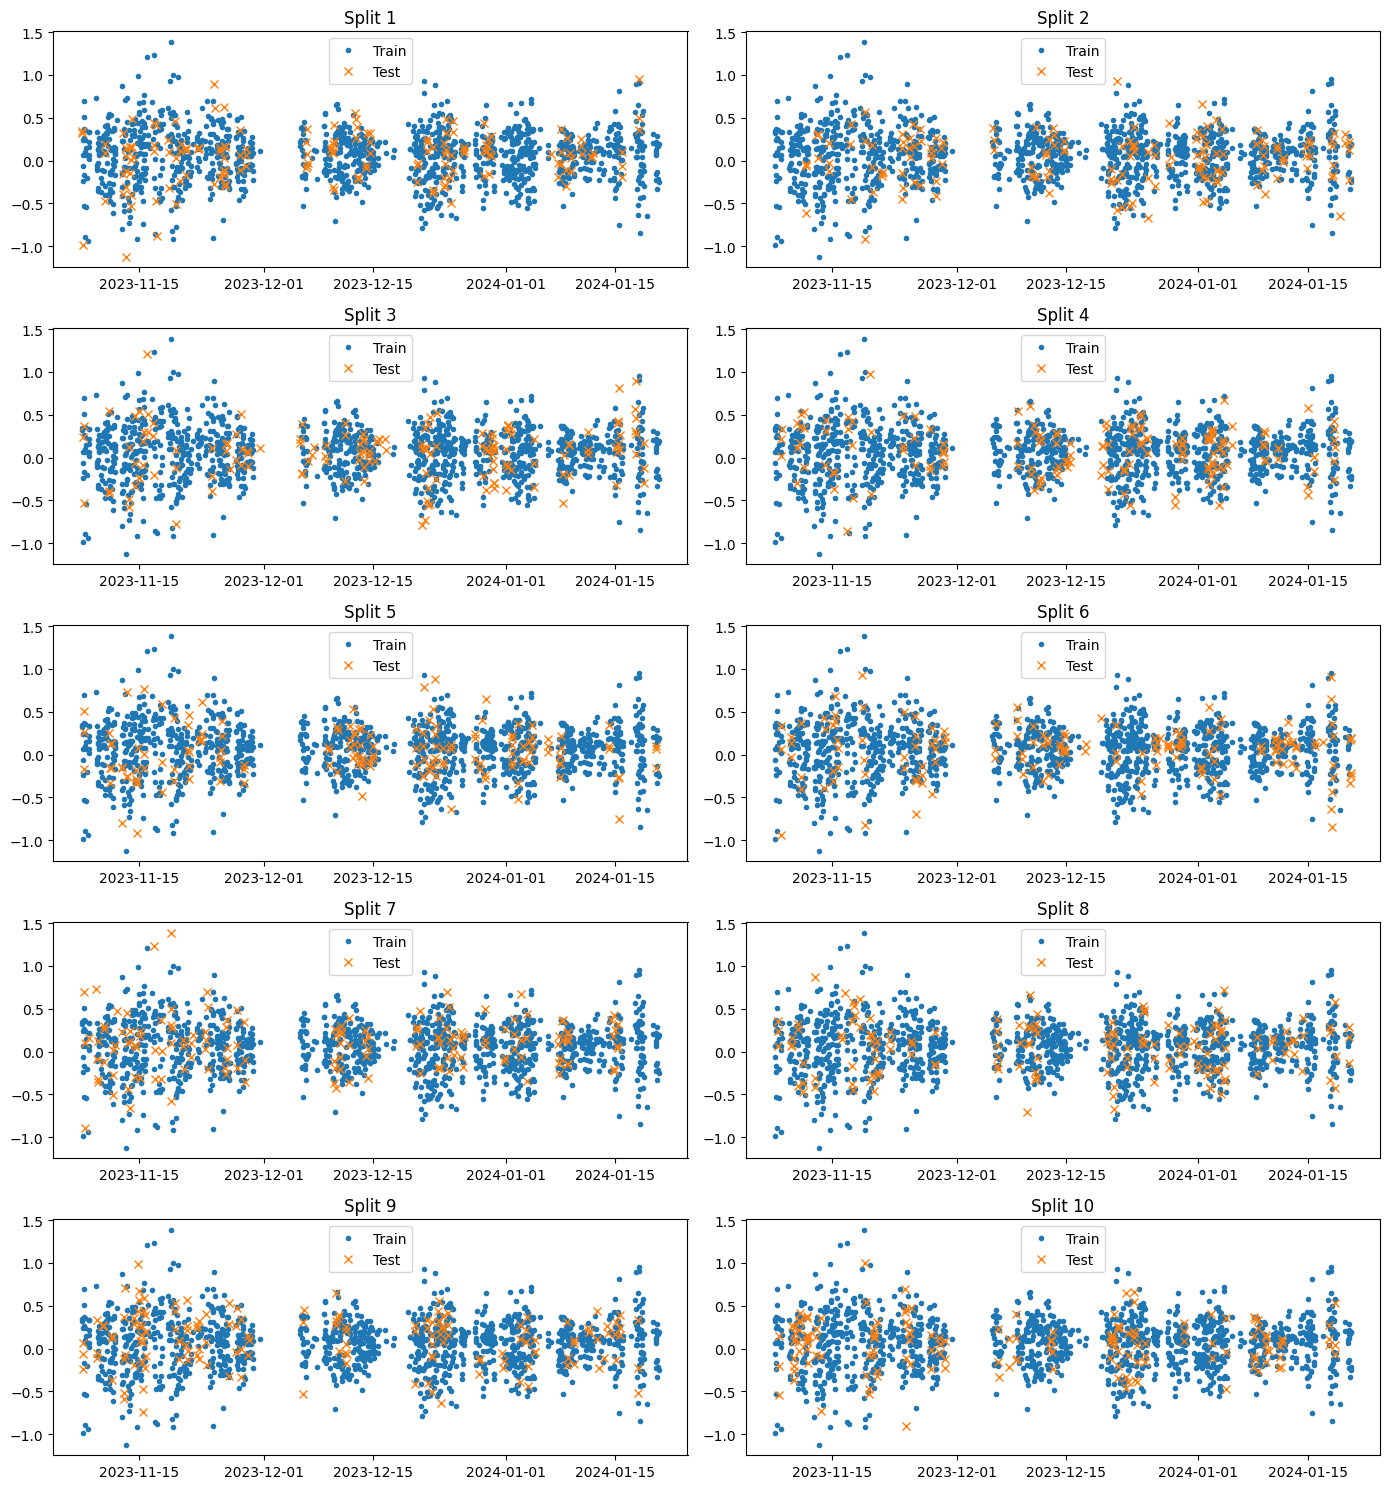

Train RMSE per fold: [0.1731 0.1681 0.1704 0.1816 0.1722 0.1638 0.1551 0.1718 0.1675 0.1638]
Test RMSE per fold: [0.2942 0.2935 0.3252 0.2984 0.3124 0.3192 0.3226 0.3189 0.3218 0.2865]
Train R² per fold: [0.6578 0.6809 0.6648 0.6276 0.6631 0.6948 0.7223 0.6638 0.6797 0.6984]
Test R² per fold: [ 0.0334 -0.0783 -0.0761 -0.0998 -0.1457 -0.1645 -0.066  -0.1525 -0.1787
 -0.0603]


{'feature_importance': <Figure size 700x1000 with 1 Axes>,
 'obs_vs_pred_train': <Figure size 700x400 with 1 Axes>,
 'obs_vs_pred_test': <Figure size 700x400 with 1 Axes>}

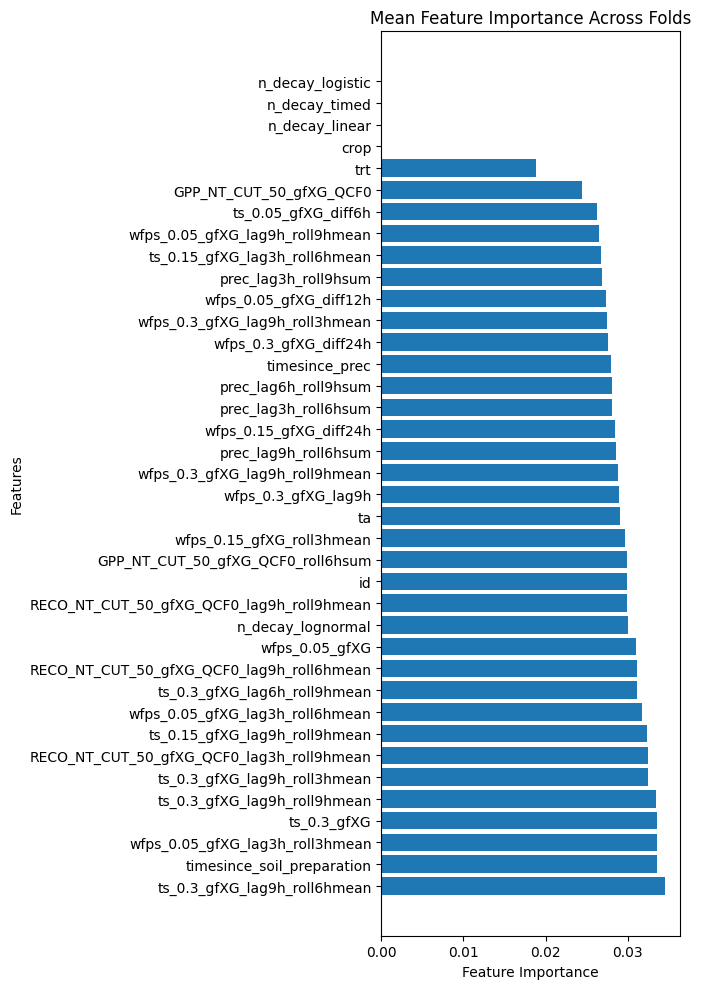

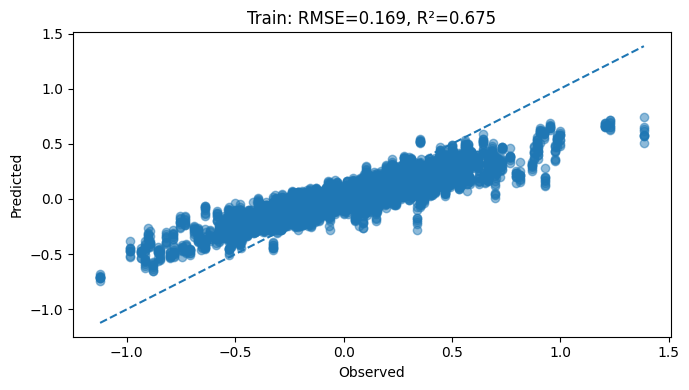

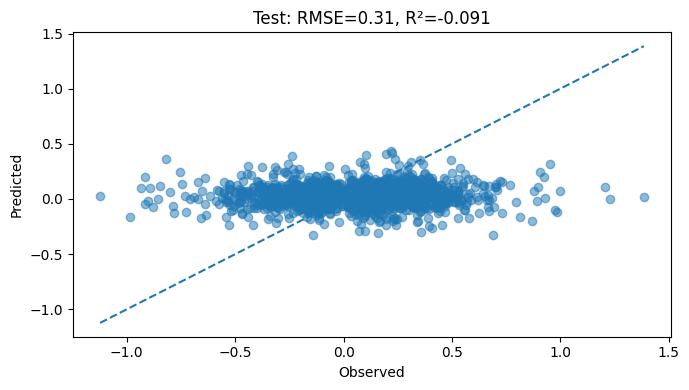

In [39]:
# Train ONE model --> we train only one model for both parcels and both QCF and QCF0
print("Started training of the gapfilling model")
fit = fit_gapfill_ts(
    data_main,
    target_col=TARGET,
    feature_cols=selected_features,
    model_factory=model_factory,
    log_transform=LOG_TRANSFORM,      
    undersample=UNDERSAMPLE,    
    cv_split=0.1,             # split fraction --> e.g., 0.1: test is 10% 
    cv_block_quantile=0.8,    # defines the quantile of the gap lenghts to use as block length in the cross-val splits
    n_ens=50,                 # for sigmaEns
    ens_block_len=48,         # for time-dep block bootstrap
)
print("Finished training of the gapfilling model\n")

# Show the splits used in the cross-validation
plot_cv_splits(fit.X_tr, fit.y_raw, fit.splits, show=True)
cvres = crossval_evaluate(
    fit.X_tr,
    fit.y_tr,             # training scale
    fit.splits,
    fit.model_factory,
    inv_y=fit.inv_y,      # back-transform for plotting/metrics
    plot=True
)

# Show results of cross-validation
print("Train RMSE per fold:", np.round(cvres["train"]["rmse"], 4))
print("Test RMSE per fold:", np.round(cvres["test"]["rmse"], 4))
print("Train R² per fold:", np.round(cvres["train"]["r2"], 4))
print("Test R² per fold:", np.round(cvres["test"]["r2"], 4))
# Show feature importance and obs vs pred plots
cvres["figures"]  # dict with "obs_vs_pred_train", "obs_vs_pred_test", maybe "feature_importance"

### SHAP CHECK

In [40]:
SHAP_CHECK = False

if SHAP_CHECK:
    # define background dataset
    background_dataset = data_main[selected_features]
    # Initialize the SHAP explainer
    explainer = shap.TreeExplainer(fit.model_final, data=background_dataset)
    # Calculate SHAP values for the entire dataset
    X = data_main[selected_features]
    shap_values = explainer(X, check_additivity=True)
    # Summary plot
    fig = plt.figure()
    shap.summary_plot(shap_values, X, show=False)
    # Save the figure
    fig.savefig(f'plots/{TARGET}_shap_summary_plot.png', dpi=300, bbox_inches='tight')
    plt.show()

    # Scatterplots
    for var in X.columns:
        shap.plots.scatter(shap_values[:, var], dot_size=3, x_jitter=0.5, color=shap_values)
        plt.show()

### GAPFILLING (+ COMPUTING GF UNCERTAINTY) 

In [41]:
# Build the 3 “views” that share EXACTLY the same feature columns (selected_features)
df_fp = data_main.copy()  # footprint: X is just data_main[selected_features] already
df_A = build_df_for_parcel(data_main, TARGET_FLUX, "A", selected_features, add_trt=ADD_TRT)
df_B = build_df_for_parcel(data_main, TARGET_FLUX, "B", selected_features, add_trt=ADD_TRT)

# Compute model predictions + uncertainties ONCE per view
print("Predict and compute uncertainty for the full footprint\n")
pred_fp = apply_gapfill_ts(df_fp, fit, prefix="GF_FP")
print("Predict and compute uncertainty for parcel A\n")
pred_A  = apply_gapfill_ts(df_A,  fit, prefix="GF_A")
print("Predict and compute uncertainty for parcel B\n")
pred_B  = apply_gapfill_ts(df_B,  fit, prefix="GF_B")

# Helper to gapfill each version
def fill_from_pred(df_view, pred_df, qc, name):
    target_base = f"{TARGET_FLUX}_L3.3_{USTAR_CUT}"
    y_obs = df_view[f"{target_base}_{qc}"].astype(float)
    y_hat = pred_df[f"{target_base}_yhat"]
    gap = y_obs.isna() & y_hat.notna()
    out = pred_df.copy()
    out[f"{target_base}_{qc}_{name}_gf{MODEL_TYPE}_ISFILLED"] = gap
    out[f"{target_base}_{qc}_{name}_gf{MODEL_TYPE}"] = y_obs.where(~gap, y_hat)
    return out

target_base = f"{TARGET_FLUX}_L3.3_{USTAR_CUT}_"

outputs = {}
for qc in ["QCF", "QCF0"]:
    outputs[("footprint", qc)] = fill_from_pred(df_fp, pred_fp, qc, "footprint")
    outputs[("parcelA",  qc)]  = fill_from_pred(df_A,  pred_A,  qc, "parcelA")
    outputs[("parcelB",  qc)]  = fill_from_pred(df_B,  pred_B,  qc, "parcelB")

Predict and compute uncertainty for the full footprint

Predict and compute uncertainty for parcel A

Predict and compute uncertainty for parcel B



KeyError: 'FN2O_L3.3_CUT_50_yhat'

In [42]:
pred_B

,GPP_NT_CUT_50_gfXG_QCF0,ta,timesince_prec,ts_0.3_gfXG,wfps_0.05_gfXG,crop,timesince_soil_preparation,wfps_0.3_gfXG_lag9h,GPP_NT_CUT_50_gfXG_QCF0_roll6hsum,wfps_0.15_gfXG_roll3hmean,RECO_NT_CUT_50_gfXG_QCF0_lag3h_roll9hmean,RECO_NT_CUT_50_gfXG_QCF0_lag9h_roll6hmean,RECO_NT_CUT_50_gfXG_QCF0_lag9h_roll9hmean,prec_lag3h_roll6hsum,prec_lag3h_roll9hsum,...,wfps_0.15_gfXG_diff24h,wfps_0.3_gfXG_diff24h,n_decay_linear,n_decay_logistic,n_decay_lognormal,n_decay_timed,id,trt,FN2O_L3.3_CUT_50_QCF,FN2O_L3.3_CUT_50_QCF0,FN2O_RANDUNC_HF,GF_B_yhat,GF_B_sigmaEns,GF_B_sigmaResid,GF_B_sigmaGF
TIMESTAMP_MIDDLE,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2023-11-07 15:45:00,1.734944,7.366667,35.0,11.129708,45.247686,1.0,21,42.541018,69.902178,55.236985,1.672170,1.585342,1.596489,0.000,0.000,...,-0.431489,0.396048,0.0,0.0,1.041116,29.0,31,1,NaN,NaN,0.205045,0.147316,0.116643,0.260991,0.285870
2023-11-07 16:15:00,0.935265,7.300000,36.0,11.314175,45.215566,1.0,21,42.763191,63.537492,55.223917,1.678798,1.590457,1.598664,0.000,0.000,...,-0.444220,0.460355,0.0,0.0,1.037818,29.0,32,1,0.324973,0.324973,0.124789,0.209569,0.116245,0.283099,0.306036
2023-11-07 17:15:00,0.130147,6.600000,0.0,11.401140,45.038043,1.0,21,43.061405,48.429520,55.166433,1.686493,1.609214,1.600855,0.000,0.000,...,-0.431704,0.889783,0.0,0.0,1.031258,29.0,34,1,0.339963,0.339963,0.264532,-0.166535,0.104706,0.288920,0.307308
2023-11-07 17:45:00,0.131321,6.633333,0.0,11.384078,45.130002,1.0,21,42.960006,42.764295,55.154131,1.689364,1.621063,1.602265,0.000,0.000,...,-0.346287,1.462444,0.0,0.0,1.027996,29.0,35,1,-0.983566,-0.983566,0.344428,-0.492349,0.277483,0.288920,0.400589
2023-11-07 18:15:00,0.101225,6.366667,0.0,11.183588,47.646389,1.0,21,42.961644,35.064349,55.159320,1.690391,1.635560,1.606155,0.000,0.000,...,-0.150212,1.930903,0.0,0.0,1.024747,29.0,36,1,-0.064456,-0.064456,0.172716,-0.235228,0.112909,0.288920,0.310199
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-01-21 21:15:00,-0.438207,-4.183333,6.0,2.033333,40.406381,1.0,60,42.705954,-1.913805,55.650420,1.231991,0.977664,0.948513,0.578,0.578,...,-0.125180,-0.334300,0.0,0.0,0.000000,0.0,3642,1,0.414013,NaN,0.188048,0.027553,0.049858,0.288920,0.293190
2024-01-21 21:45:00,-0.456867,-4.633333,7.0,2.020667,40.387756,1.0,60,42.660940,-3.770041,55.684037,1.253418,1.003011,0.961971,0.578,0.578,...,-0.123191,-0.290830,0.0,0.0,0.000000,0.0,3643,1,0.146925,NaN,0.050344,0.005888,0.052796,0.288920,0.293704
2024-01-21 22:15:00,-0.453651,-4.553333,8.0,2.008667,40.378045,1.0,60,42.553522,-4.456622,55.704919,1.275089,1.028903,0.978234,0.578,0.578,...,-0.127262,-0.264085,0.0,0.0,0.000000,0.0,3644,1,0.153939,NaN,0.093637,0.001408,0.053601,0.288920,0.293850


In [24]:
outputs[('parcelA', 'QCF')]

,GPP_NT_CUT_50_gfXG_QCF0,ta,timesince_prec,ts_0.3_gfXG,wfps_0.05_gfXG,crop,timesince_soil_preparation,wfps_0.3_gfXG_lag9h,GPP_NT_CUT_50_gfXG_QCF0_roll6hsum,wfps_0.15_gfXG_roll3hmean,RECO_NT_CUT_50_gfXG_QCF0_lag3h_roll9hmean,RECO_NT_CUT_50_gfXG_QCF0_lag9h_roll6hmean,RECO_NT_CUT_50_gfXG_QCF0_lag9h_roll9hmean,prec_lag3h_roll6hsum,prec_lag3h_roll9hsum,...,n_decay_linear,n_decay_logistic,n_decay_lognormal,n_decay_timed,id,trt,FN2O_L3.3_CUT_50_QCF,FN2O_L3.3_CUT_50_QCF0,FN2O_RANDUNC_HF,GF_A_yhat,GF_A_sigmaEns,GF_A_sigmaResid,GF_A_sigmaGF,GF_A_QCF_is_gapfilled,GF_A_QCF_filled
TIMESTAMP_MIDDLE,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2023-11-07 15:45:00,1.734944,7.366667,35.0,11.129708,45.247686,1.0,21,42.541018,69.902178,55.236985,1.672170,1.585342,1.596489,0.0,0.0,...,0.0,0.0,1.041116,29.0,31,0,NaN,NaN,NaN,0.040008,0.199715,0.228834,0.303728,True,0.040008
2023-11-07 16:15:00,0.935265,7.300000,36.0,11.314175,45.215566,1.0,21,42.763191,63.537492,55.223917,1.678798,1.590457,1.598664,0.0,0.0,...,0.0,0.0,1.037818,29.0,32,0,NaN,NaN,NaN,0.056121,0.208198,0.221707,0.304139,True,0.056121
2023-11-07 17:15:00,0.130147,6.600000,0.0,11.401140,45.038043,1.0,21,43.061405,48.429520,55.166433,1.686493,1.609214,1.600855,0.0,0.0,...,0.0,0.0,1.031258,29.0,34,0,NaN,NaN,NaN,-0.134884,0.229055,0.228834,0.323777,True,-0.134884
2023-11-07 17:45:00,0.131321,6.633333,0.0,11.384078,45.130002,1.0,21,42.960006,42.764295,55.154131,1.689364,1.621063,1.602265,0.0,0.0,...,0.0,0.0,1.027996,29.0,35,0,NaN,NaN,NaN,-0.326917,0.355277,0.228834,0.422595,True,-0.326917
2023-11-07 18:15:00,0.101225,6.366667,0.0,11.183588,47.646389,1.0,21,42.961644,35.064349,55.159320,1.690391,1.635560,1.606155,0.0,0.0,...,0.0,0.0,1.024747,29.0,36,0,NaN,NaN,NaN,-0.059785,0.260523,0.228834,0.346752,True,-0.059785
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-08-21 21:45:00,0.215444,13.353333,127.0,20.294815,28.993050,2.0,17,42.666867,21.878991,44.867923,5.017753,4.872343,4.849460,0.0,0.0,...,0.0,0.0,0.000000,0.0,13867,0,NaN,NaN,NaN,1.570073,0.744212,0.466667,0.878424,True,1.570073
2024-08-21 22:15:00,0.368136,12.743333,128.0,20.274073,28.920284,2.0,17,42.662008,17.880872,44.841537,5.018561,4.886213,4.865538,0.0,0.0,...,0.0,0.0,0.000000,0.0,13868,0,NaN,NaN,NaN,1.549277,0.730679,0.466667,0.866988,True,1.549277
2024-08-21 22:45:00,0.344892,12.346667,129.0,20.234073,28.873327,2.0,17,42.633439,14.185675,44.815802,5.011717,4.898210,4.880233,0.0,0.0,...,0.0,0.0,0.000000,0.0,13869,0,NaN,NaN,NaN,1.535642,0.731293,0.466667,0.867507,True,1.535642


In [16]:
import numpy as np
import matplotlib.pyplot as plt

def plot_gapfill_timeseries(
    df,
    *,
    time_col=None,               # if index is datetime, leave None
    obs_col,                     # observed column you are filling (e.g. "..._QCF")
    filled_col,                  # your final series (e.g. "GF_FP_QCF_filled")
    yhat_col,                    # model prediction (e.g. "GF_FP_yhat")
    sigma_col=None,              # e.g. "GF_FP_sigmaGF" (or sigmaEns/sigmaResid)
    is_gapfilled_col=None,       # e.g. "GF_FP_QCF_is_gapfilled"
    start=None, end=None,
    band_sigma=2.0,              # 1=~68%, 2=~95%
    title=None,
    show=True
):
    d = df.copy()

    # x-axis
    if time_col is None:
        x = d.index
    else:
        x = d[time_col]

    # subset time
    if start is not None or end is not None:
        mask = np.ones(len(d), dtype=bool)
        if start is not None:
            mask &= (x >= start)
        if end is not None:
            mask &= (x <= end)
        d = d.loc[mask]
        x = x[mask]

    y_obs    = d[obs_col]
    y_fill   = d[filled_col]
    y_hat    = d[yhat_col]
    gap_mask = d[is_gapfilled_col] if is_gapfilled_col is not None else (y_obs.isna() & y_hat.notna())

    fig, ax = plt.subplots(figsize=(12, 4))

    # uncertainty band around model prediction
    if sigma_col is not None:
        sig = d[sigma_col]
        lo = y_hat - band_sigma * sig
        hi = y_hat + band_sigma * sig
        ax.fill_between(x, lo, hi, alpha=0.25, label=f"±{band_sigma}σ ({sigma_col})")

    # model prediction line (optional but useful)
    ax.plot(x, y_hat, linewidth=1, alpha=0.8, label="model yhat")

    # observed points
    ax.plot(x, y_obs, linewidth=0, marker=".", alpha=1, label="observed")

    # filled series line (shows final)
    ax.plot(x, y_fill, linewidth=1.5, alpha=0.9, label="filled")

    ax.set_title(title or "Gapfill check")
    ax.set_xlabel("time")
    ax.set_ylabel(obs_col)
    ax.legend(loc="best", frameon=False)
    plt.tight_layout()
    if show:
        plt.show()
    return fig, ax


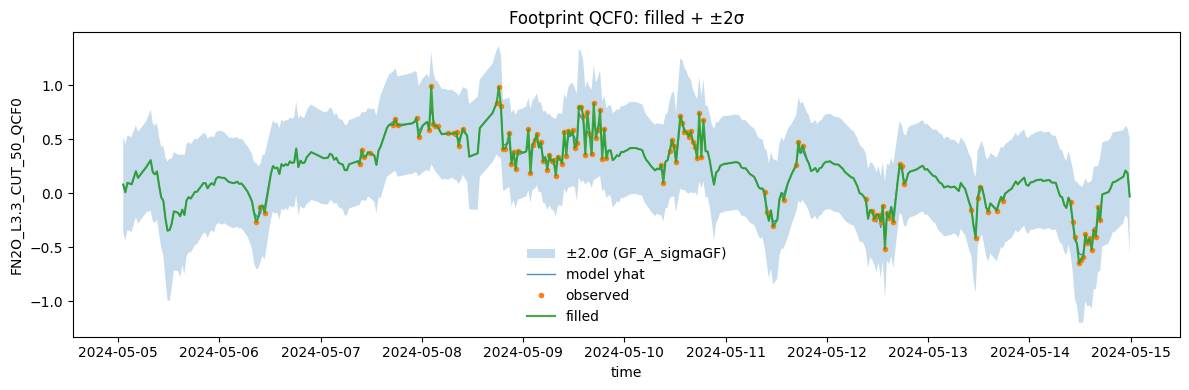

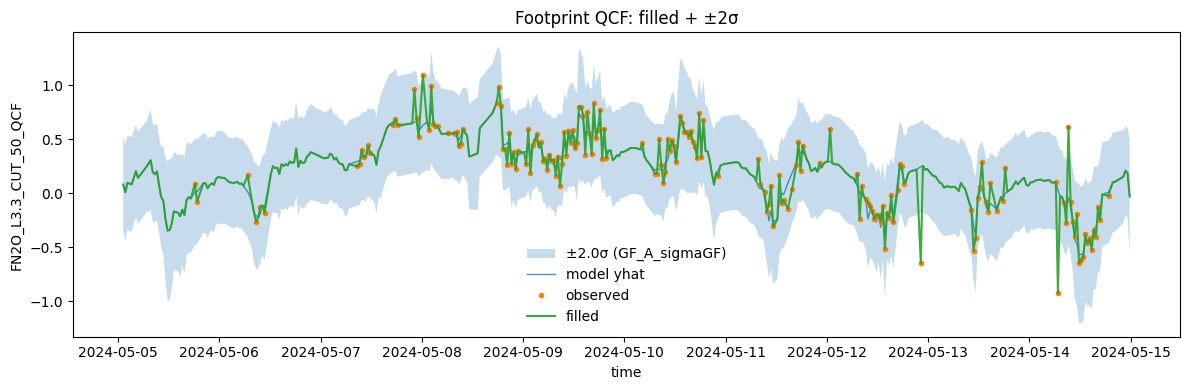

(<Figure size 1200x400 with 1 Axes>,
 <Axes: title={'center': 'Footprint QCF: filled + ±2σ'}, xlabel='time', ylabel='FN2O_L3.3_CUT_50_QCF'>)

In [33]:
qcf = 'QCF0'
parcel = 'A'
df_out = outputs[(f"parcel{parcel}", qcf)]

target_base = f"{TARGET_FLUX}_L3.3_CUT_50"
obs_col     = f"{target_base}_{qcf}"

plot_gapfill_timeseries(
    df_out,
    obs_col=obs_col,
    filled_col=f"GF_{parcel}_{qcf}_filled",
    yhat_col=f"GF_{parcel}_yhat",
    sigma_col=f"GF_{parcel}_sigmaGF",
    is_gapfilled_col=f"GF_{parcel}_{qcf}_is_gapfilled",
    start="2024-05-05",
    end="2024-05-15",
    band_sigma=2.0,
    title=f"Footprint {qcf}: filled + ±2σ"
)

qcf = 'QCF'
parcel = 'A'
df_out = outputs[(f"parcel{parcel}", qcf)]

target_base = f"{TARGET_FLUX}_L3.3_CUT_50"
obs_col     = f"{target_base}_{qcf}"

plot_gapfill_timeseries(
    df_out,
    obs_col=obs_col,
    filled_col=f"GF_{parcel}_{qcf}_filled",
    yhat_col=f"GF_{parcel}_yhat",
    sigma_col=f"GF_{parcel}_sigmaGF",
    is_gapfilled_col=f"GF_{parcel}_{qcf}_is_gapfilled",
    start="2024-05-05",
    end="2024-05-15",
    band_sigma=2.0,
    title=f"Footprint {qcf}: filled + ±2σ"
)

In [29]:
outputs[("parcelB", "QCF0")]

,GPP_NT_CUT_50_gfXG_QCF0,ta,timesince_prec,ts_0.3_gfXG,wfps_0.05_gfXG,crop,timesince_soil_preparation,wfps_0.3_gfXG_lag9h,GPP_NT_CUT_50_gfXG_QCF0_roll6hsum,wfps_0.15_gfXG_roll3hmean,RECO_NT_CUT_50_gfXG_QCF0_lag3h_roll9hmean,RECO_NT_CUT_50_gfXG_QCF0_lag9h_roll6hmean,RECO_NT_CUT_50_gfXG_QCF0_lag9h_roll9hmean,prec_lag3h_roll6hsum,prec_lag3h_roll9hsum,...,n_decay_linear,n_decay_logistic,n_decay_lognormal,n_decay_timed,id,trt,FN2O_L3.3_CUT_50_QCF,FN2O_L3.3_CUT_50_QCF0,FN2O_RANDUNC_HF,GF_B_yhat,GF_B_sigmaEns,GF_B_sigmaResid,GF_B_sigmaGF,GF_B_QCF0_is_gapfilled,GF_B_QCF0_filled
TIMESTAMP_MIDDLE,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2024-05-05 01:15:00,0.612230,13.820000,86.0,12.828148,27.524279,1.0,60,35.389142,-3.143662,50.374669,6.843322,6.937419,6.763464,0.000,0.000,...,0.000000,0.000000,1.506778,0.0,2,1,0.234981,0.234981,0.174895,0.106516,0.104495,0.199414,0.225134,False,0.234981
2024-05-05 01:45:00,-1.285381,14.170000,87.0,12.778890,27.522578,1.0,60,35.368544,-4.784045,50.363395,6.801861,6.981042,6.807833,0.000,0.000,...,0.000000,0.000000,1.502463,0.0,3,1,-0.057034,-0.057034,0.221469,0.021725,0.093275,0.199414,0.220151,False,-0.057034
2024-05-05 02:15:00,-2.972770,13.973333,88.0,12.705185,27.504656,1.0,60,35.362416,-7.674622,50.354777,6.759655,7.009900,6.845105,0.000,0.000,...,0.000000,0.000000,1.498163,0.0,4,1,0.164116,0.164116,0.169528,0.106035,0.089373,0.199414,0.218526,False,0.164116
2024-05-05 02:45:00,-2.217341,13.850000,89.0,12.700000,27.495362,1.0,60,35.341416,-9.517395,50.345646,6.719300,7.035068,6.882317,0.000,0.000,...,0.000000,0.000000,1.493877,0.0,5,1,0.090103,0.090103,0.245638,0.097590,0.088301,0.199414,0.218090,False,0.090103
2024-05-05 03:15:00,-1.938147,13.403333,90.0,12.692593,27.492093,1.0,60,35.337110,-10.762484,50.337259,6.678691,7.056153,6.916515,0.000,0.000,...,0.000000,0.000000,1.489605,0.0,6,1,0.048111,0.048111,0.170684,0.090011,0.087211,0.199414,0.217650,False,0.048111
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-05-21 19:15:00,4.504963,13.723333,9.0,14.525554,36.695616,1.0,60,33.423793,232.721387,50.071541,7.853771,7.818180,7.878891,4.488,6.936,...,18.210317,24.422999,14.712168,26.0,806,1,NaN,NaN,NaN,0.395345,0.103088,0.199414,0.224484,True,0.395345
2024-05-21 20:45:00,-0.230669,11.856667,12.0,14.538517,36.551795,1.0,60,33.336837,151.771104,50.213807,7.880586,7.829471,7.847412,3.230,5.882,...,18.132937,24.377968,14.518977,26.0,809,1,NaN,NaN,NaN,0.417781,0.116404,0.199414,0.230902,True,0.417781
2024-05-21 21:15:00,0.005106,11.983333,13.0,14.543332,36.515008,1.0,60,33.377056,121.073863,50.263436,7.887725,7.835175,7.840949,2.805,5.593,...,18.107143,24.362693,14.455078,26.0,810,1,NaN,NaN,NaN,0.405154,0.124114,0.199414,0.234883,True,0.405154


In [ ]:
outputs[("parcelB", "QCF0")]['GF_B_QCF0_filled'].plot()
outputs[("parcelA", "QCF0")]['GF_A_QCF0_filled'].plot()

In [ ]:
outputs[("parcelB", "QCF0")]['GF_B_QCF0_filled'].plot()
plt.show()
outputs[("parcelA", "QCF0")]['GF_A_QCF0_filled'].plot()
plt.show()

# EXPORT

In [ ]:
newcols = [c for c in data_main.columns if c not in maindf if f'gf{MODEL_TYPE}' in c]
print(f"NEW VARIABLES FROM GAP-FILLING {TARGET_FLUX}:")
for c in newcols:
    print(f"+ {c}")

In [ ]:
filename = f"82.4.1_{TARGET_FLUX}_GF-{MODEL_TYPE}"
df_export = data_main[newcols]
save_parquet(data=df_export, filename=filename)

# End of notebook

In [ ]:
dt_string = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
print(f"Finished. {dt_string}")